In [3]:
pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:

df = pd.read_csv("retail_sales_dataset.csv")
df.head()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types and Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Shape: (1000, 9)

Column Names:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

Data Types and Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product C

## 4. Data Cleaning and Preparation

In [4]:

# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Check duplicate records
print("Duplicate Records:", df.duplicated().sum())

# Check missing values after date conversion
print("\nMissing Values:")
print(df.isnull().sum())

# Remove duplicate records if any exist
df = df.drop_duplicates()

print("\nDataset Shape After Removing Duplicates:", df.shape)


Duplicate Records: 0

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Dataset Shape After Removing Duplicates: (1000, 9)


## 5. Descriptive Statistics

In [5]:

# General descriptive statistics
df.describe()


,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [6]:

# Calculate mean, median, mode, and standard deviation for all numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

statistics = pd.DataFrame({
    'Mean': df[numerical_cols].mean(),
    'Median': df[numerical_cols].median(),
    'Mode': [df[col].mode().iloc[0] if not df[col].mode().empty else np.nan for col in numerical_cols],
    'Standard Deviation': df[numerical_cols].std()
})

statistics


,Mean,Median,Mode,Standard Deviation
Transaction ID,500.500,500.5,1,288.819436
Age,41.392,42.0,43,13.681430
Quantity,2.514,3.0,4,1.132734
Price per Unit,179.890,50.0,50,189.681356
Total Amount,456.000,135.0,50,559.997632


## 6. Time Series Analysis - Monthly Sales Trend

In [7]:

# Create a Year-Month column
df['Year_Month'] = df['Date'].dt.to_period('M')

# Calculate monthly sales
monthly_sales = df.groupby('Year_Month')['Total Amount'].sum()

# Convert index to string for plotting
monthly_sales.index = monthly_sales.index.astype(str)

monthly_sales


Year_Month
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Name: Total Amount, dtype: int64

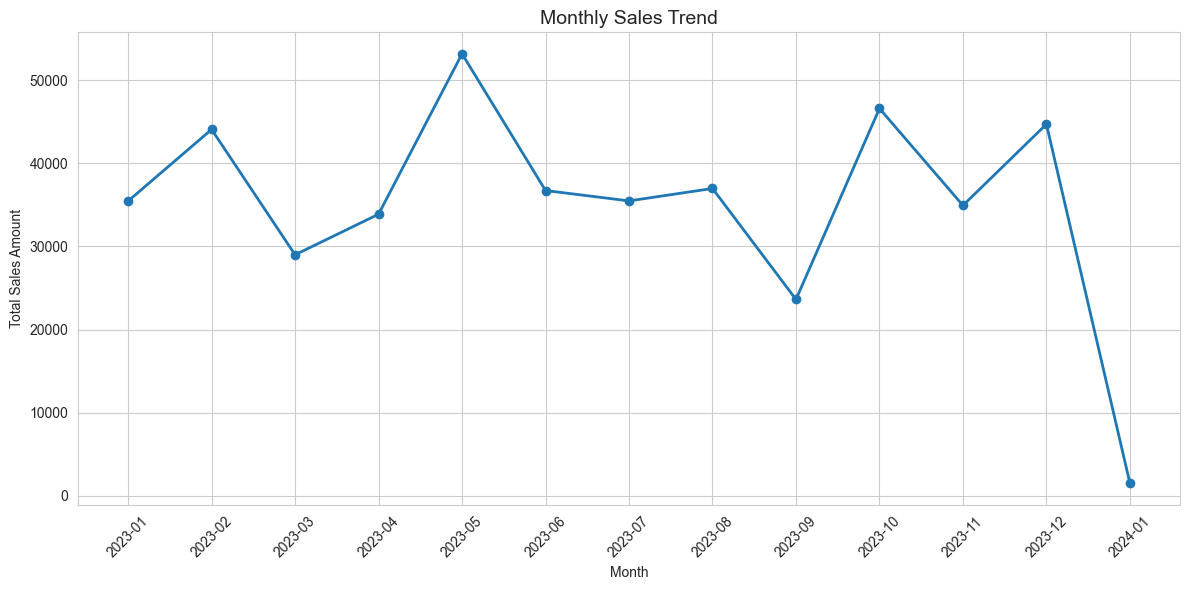

In [8]:

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linewidth=2)

plt.title("Monthly Sales Trend", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 7. Quarterly Sales Trend

In [9]:

df['Quarter'] = df['Date'].dt.to_period('Q')

quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()
quarterly_sales.index = quarterly_sales.index.astype(str)

quarterly_sales


Quarter
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Name: Total Amount, dtype: int64

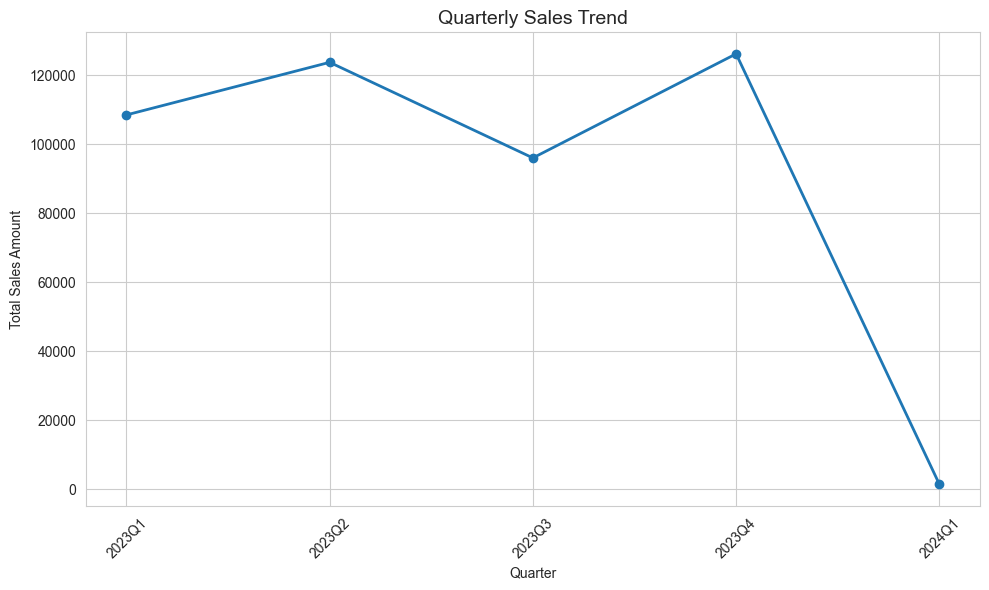

In [10]:

plt.figure(figsize=(10, 6))
plt.plot(quarterly_sales.index, quarterly_sales.values, marker='o', linewidth=2)

plt.title("Quarterly Sales Trend", fontsize=14)
plt.xlabel("Quarter")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 8. Customer Demographics Analysis - Age Groups

In [11]:

# Create age groups
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[0, 20, 30, 40, 50, 60, 100],
    labels=['Below 20', '21-30', '31-40', '41-50', '51-60', 'Above 60'],
    include_lowest=True
)

age_group_counts = df['Age Group'].value_counts().sort_index()
age_group_counts


Age Group
Below 20     63
21-30       210
31-40       193
41-50       221
51-60       220
Above 60     93
Name: count, dtype: int64

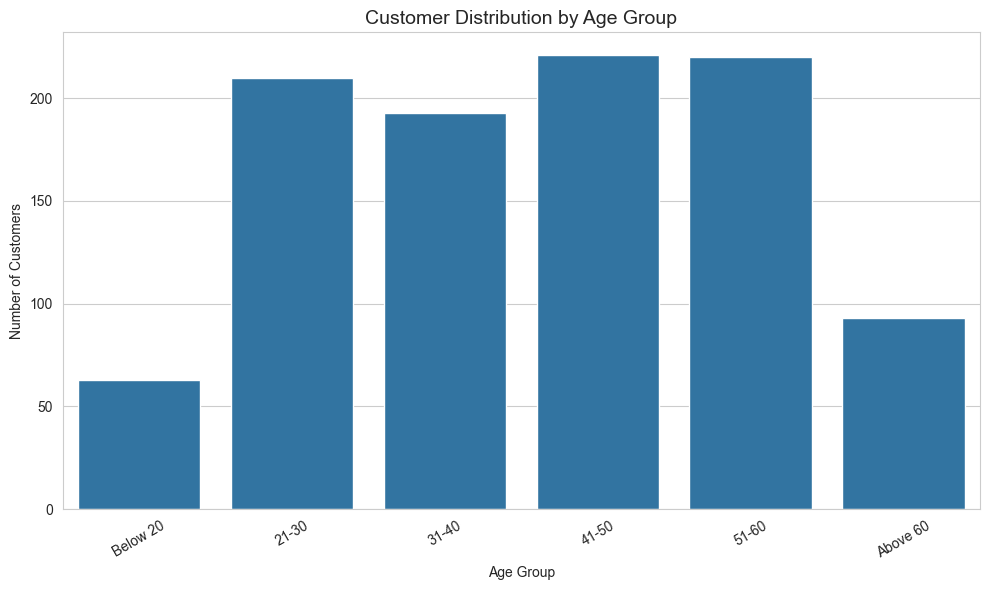

In [12]:

plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x='Age Group',
    order=df['Age Group'].cat.categories
)

plt.title("Customer Distribution by Age Group", fontsize=14)
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 9. Gender Breakdown

In [13]:

gender_counts = df['Gender'].value_counts()
gender_counts


Gender
Female    510
Male      490
Name: count, dtype: int64

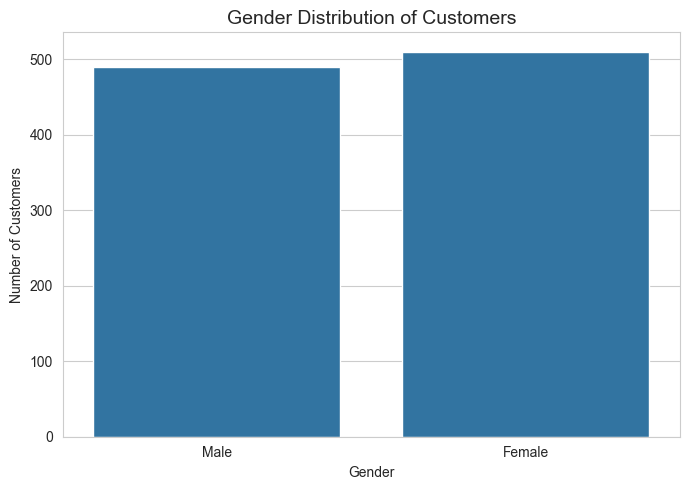

In [14]:

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Gender')

plt.title("Gender Distribution of Customers", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


## 10. Product Analysis - Best-Selling Categories by Quantity

In [15]:

# The selected dataset contains Product Category rather than individual product names.
# Therefore, sales performance is analyzed using product categories.

top_products = (
    df.groupby('Product Category')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products


Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

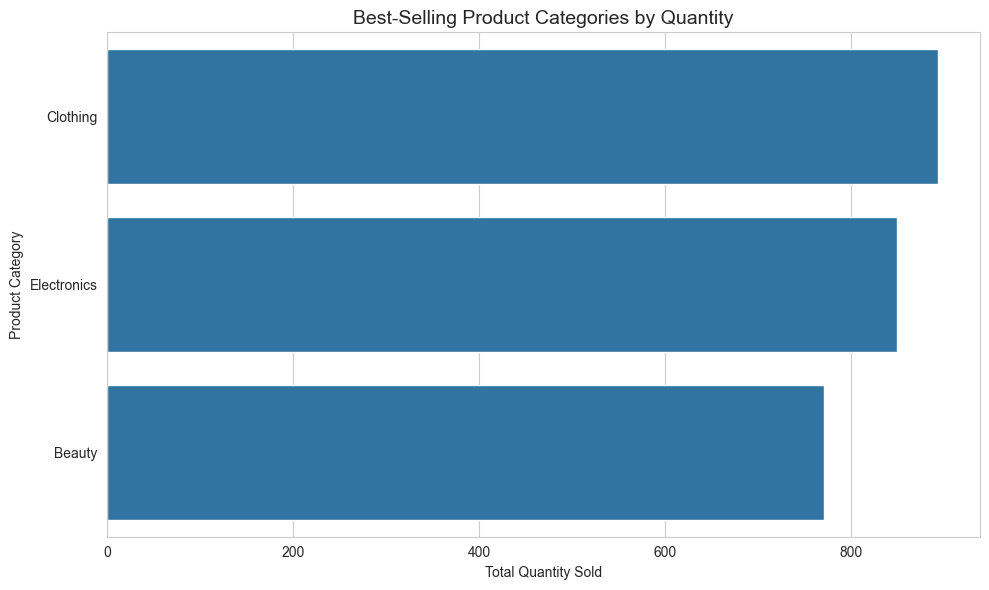

In [16]:

plt.figure(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index)

plt.title("Best-Selling Product Categories by Quantity", fontsize=14)
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()


## 11. Revenue by Product Category

In [17]:

category_revenue = (
    df.groupby('Product Category')['Total Amount']
    .sum()
    .sort_values(ascending=False)
)

category_revenue


Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

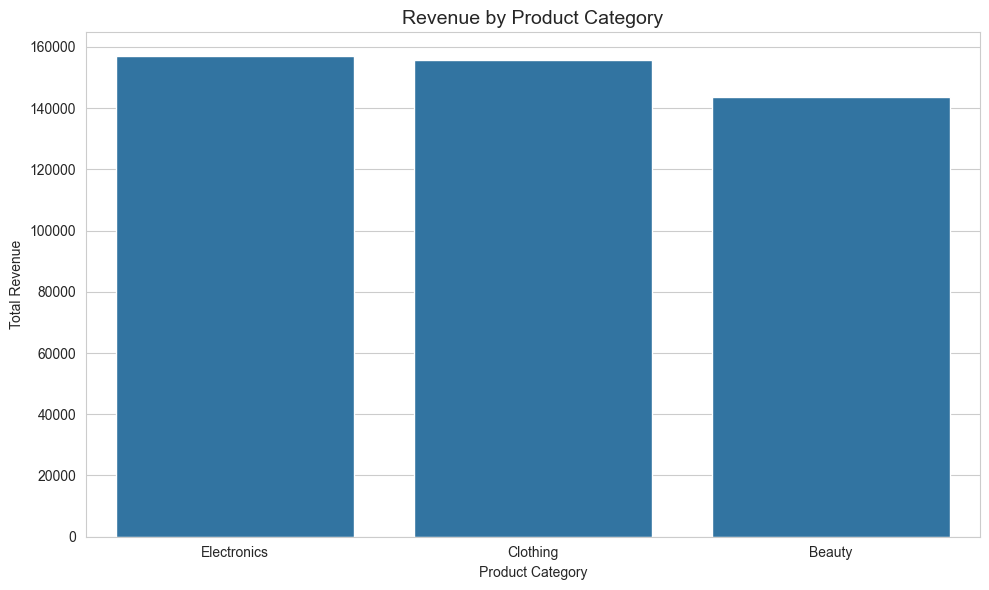

In [18]:

plt.figure(figsize=(10, 6))
sns.barplot(x=category_revenue.index, y=category_revenue.values)

plt.title("Revenue by Product Category", fontsize=14)
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()


## 12. Correlation Matrix Heatmap

In [19]:

# Select numerical columns
numerical_data = df.select_dtypes(include=np.number)

# Calculate correlation matrix
correlation_matrix = numerical_data.corr()

correlation_matrix


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
Transaction ID,1.000000,0.065191,-0.026623,-0.060837,-0.075034
Age,0.065191,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.026623,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.060837,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.075034,-0.060568,0.373707,0.851925,1.000000


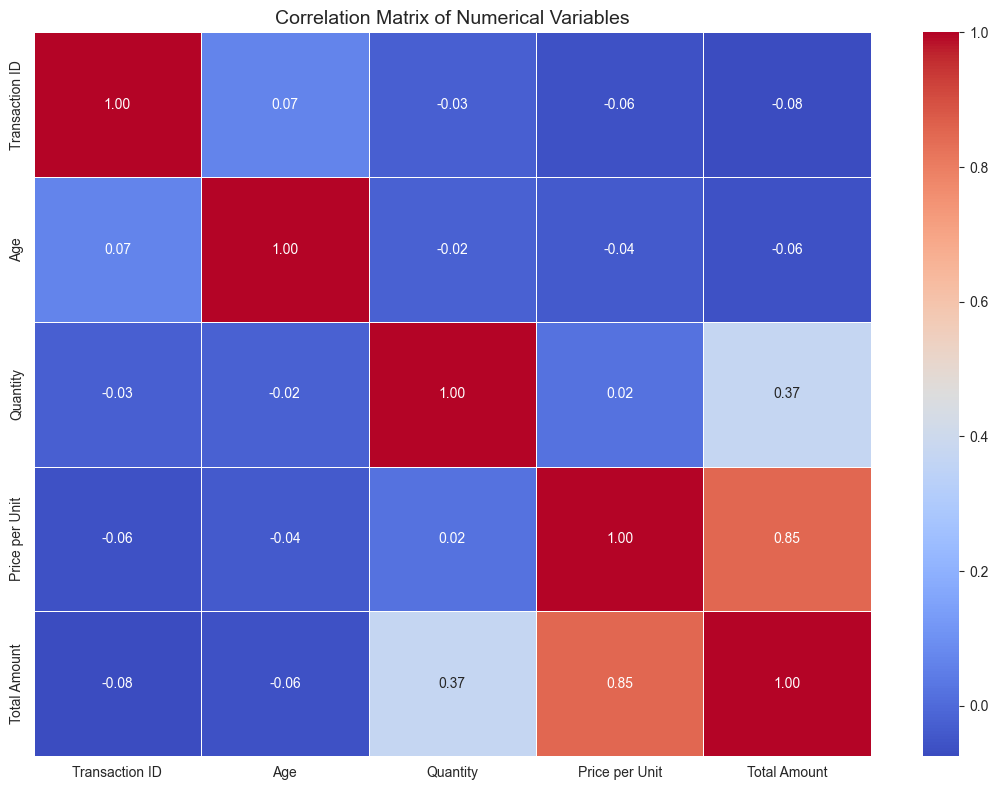

In [20]:

plt.figure(figsize=(11, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables", fontsize=14)
plt.tight_layout()
plt.show()


## 13. Additional Visualization - Average Spending by Age Group

In [21]:

avg_spending_age = (
    df.groupby('Age Group', observed=True)['Total Amount']
    .mean()
)

avg_spending_age


Age Group
Below 20    551.269841
21-30       467.690476
31-40       497.150259
41-50       424.411765
51-60       454.931818
Above 60    357.258065
Name: Total Amount, dtype: float64

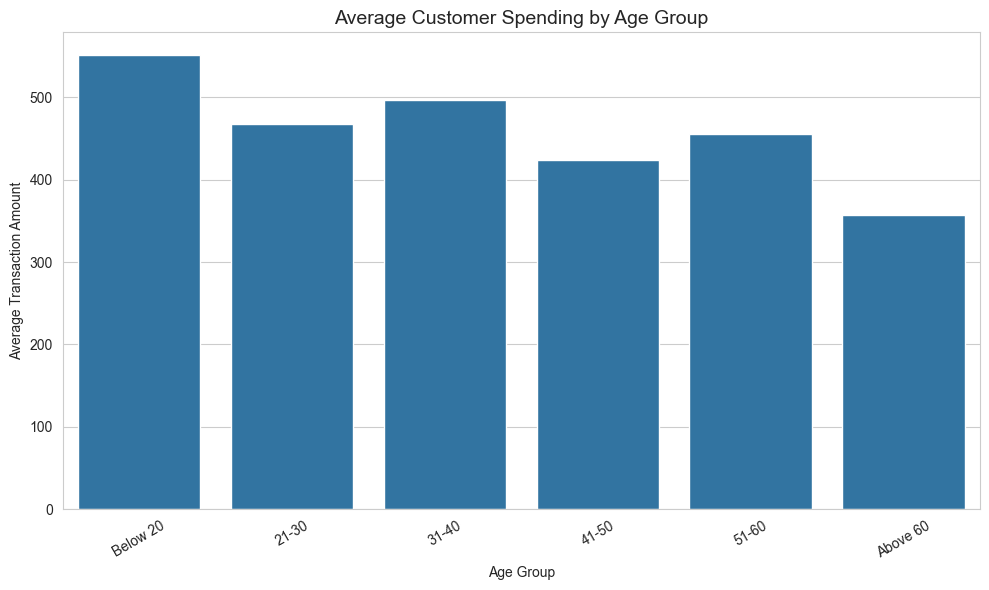

In [22]:

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_spending_age.index, y=avg_spending_age.values)

plt.title("Average Customer Spending by Age Group", fontsize=14)
plt.xlabel("Age Group")
plt.ylabel("Average Transaction Amount")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 14. Additional Customer Insight - Product Category Preference by Gender

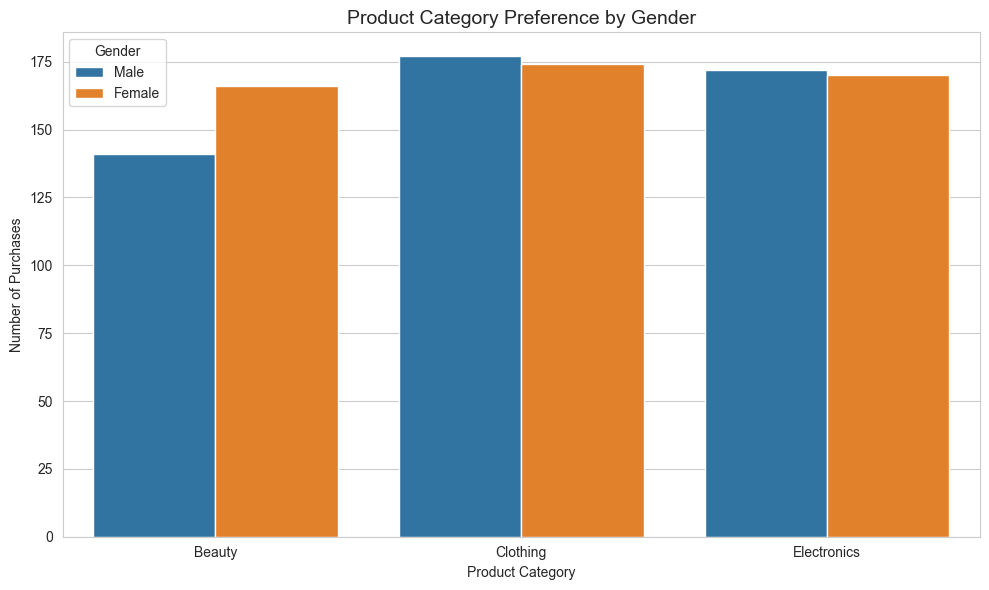

In [23]:

plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x='Product Category',
    hue='Gender'
)

plt.title("Product Category Preference by Gender", fontsize=14)
plt.xlabel("Product Category")
plt.ylabel("Number of Purchases")
plt.tight_layout()
plt.show()



# 15. Conclusion and Business Recommendations

## Key Findings

1. Sales performance changes across months and quarters, indicating possible seasonal patterns in customer purchasing behavior.
2. Customer age groups differ in purchasing frequency and average transaction spending.
3. Product categories contribute differently to sales volume and total revenue.
4. Gender-based analysis provides useful information about customer preferences across product categories.
5. Correlation analysis helps identify relationships between numerical variables such as quantity, price per unit, age, and total transaction amount.

## Actionable Business Recommendations

### 1. Focus Marketing on High-Value Customer Segments
Identify age groups with higher average transaction spending and create targeted promotions, personalized offers, and loyalty programs for these customers.

### 2. Optimize Inventory Based on Product Demand
Maintain sufficient stock for high-selling product categories and monitor low-demand categories to avoid unnecessary inventory costs.

### 3. Use Seasonal Sales Patterns for Planning
Use monthly and quarterly sales trends to plan promotional campaigns and inventory purchases before high-demand periods.

### 4. Implement Personalized Marketing Strategies
Use customer age and gender preferences to create more relevant product recommendations and advertisements.

### 5. Improve Low-Revenue Categories
Analyze low-performing categories further and consider promotional discounts, bundling strategies, or improved product positioning to increase their revenue contribution.

## Final Summary
Exploratory Data Analysis provides valuable insights into customer behavior, product performance, and sales trends. These findings can help retail businesses make data-driven decisions to improve revenue, customer satisfaction, inventory management, and marketing effectiveness.
